# Comparison: Optimal Route vs. Official Route

In our previous model (Notebook 02), we solved the shortest path problem (TSP) using Google OR-Tools. However, on the official map of **Parque de la Naturaleza de Cabárceno**, there is a "recommended order" for the visit (from enclosure 1 to 32).

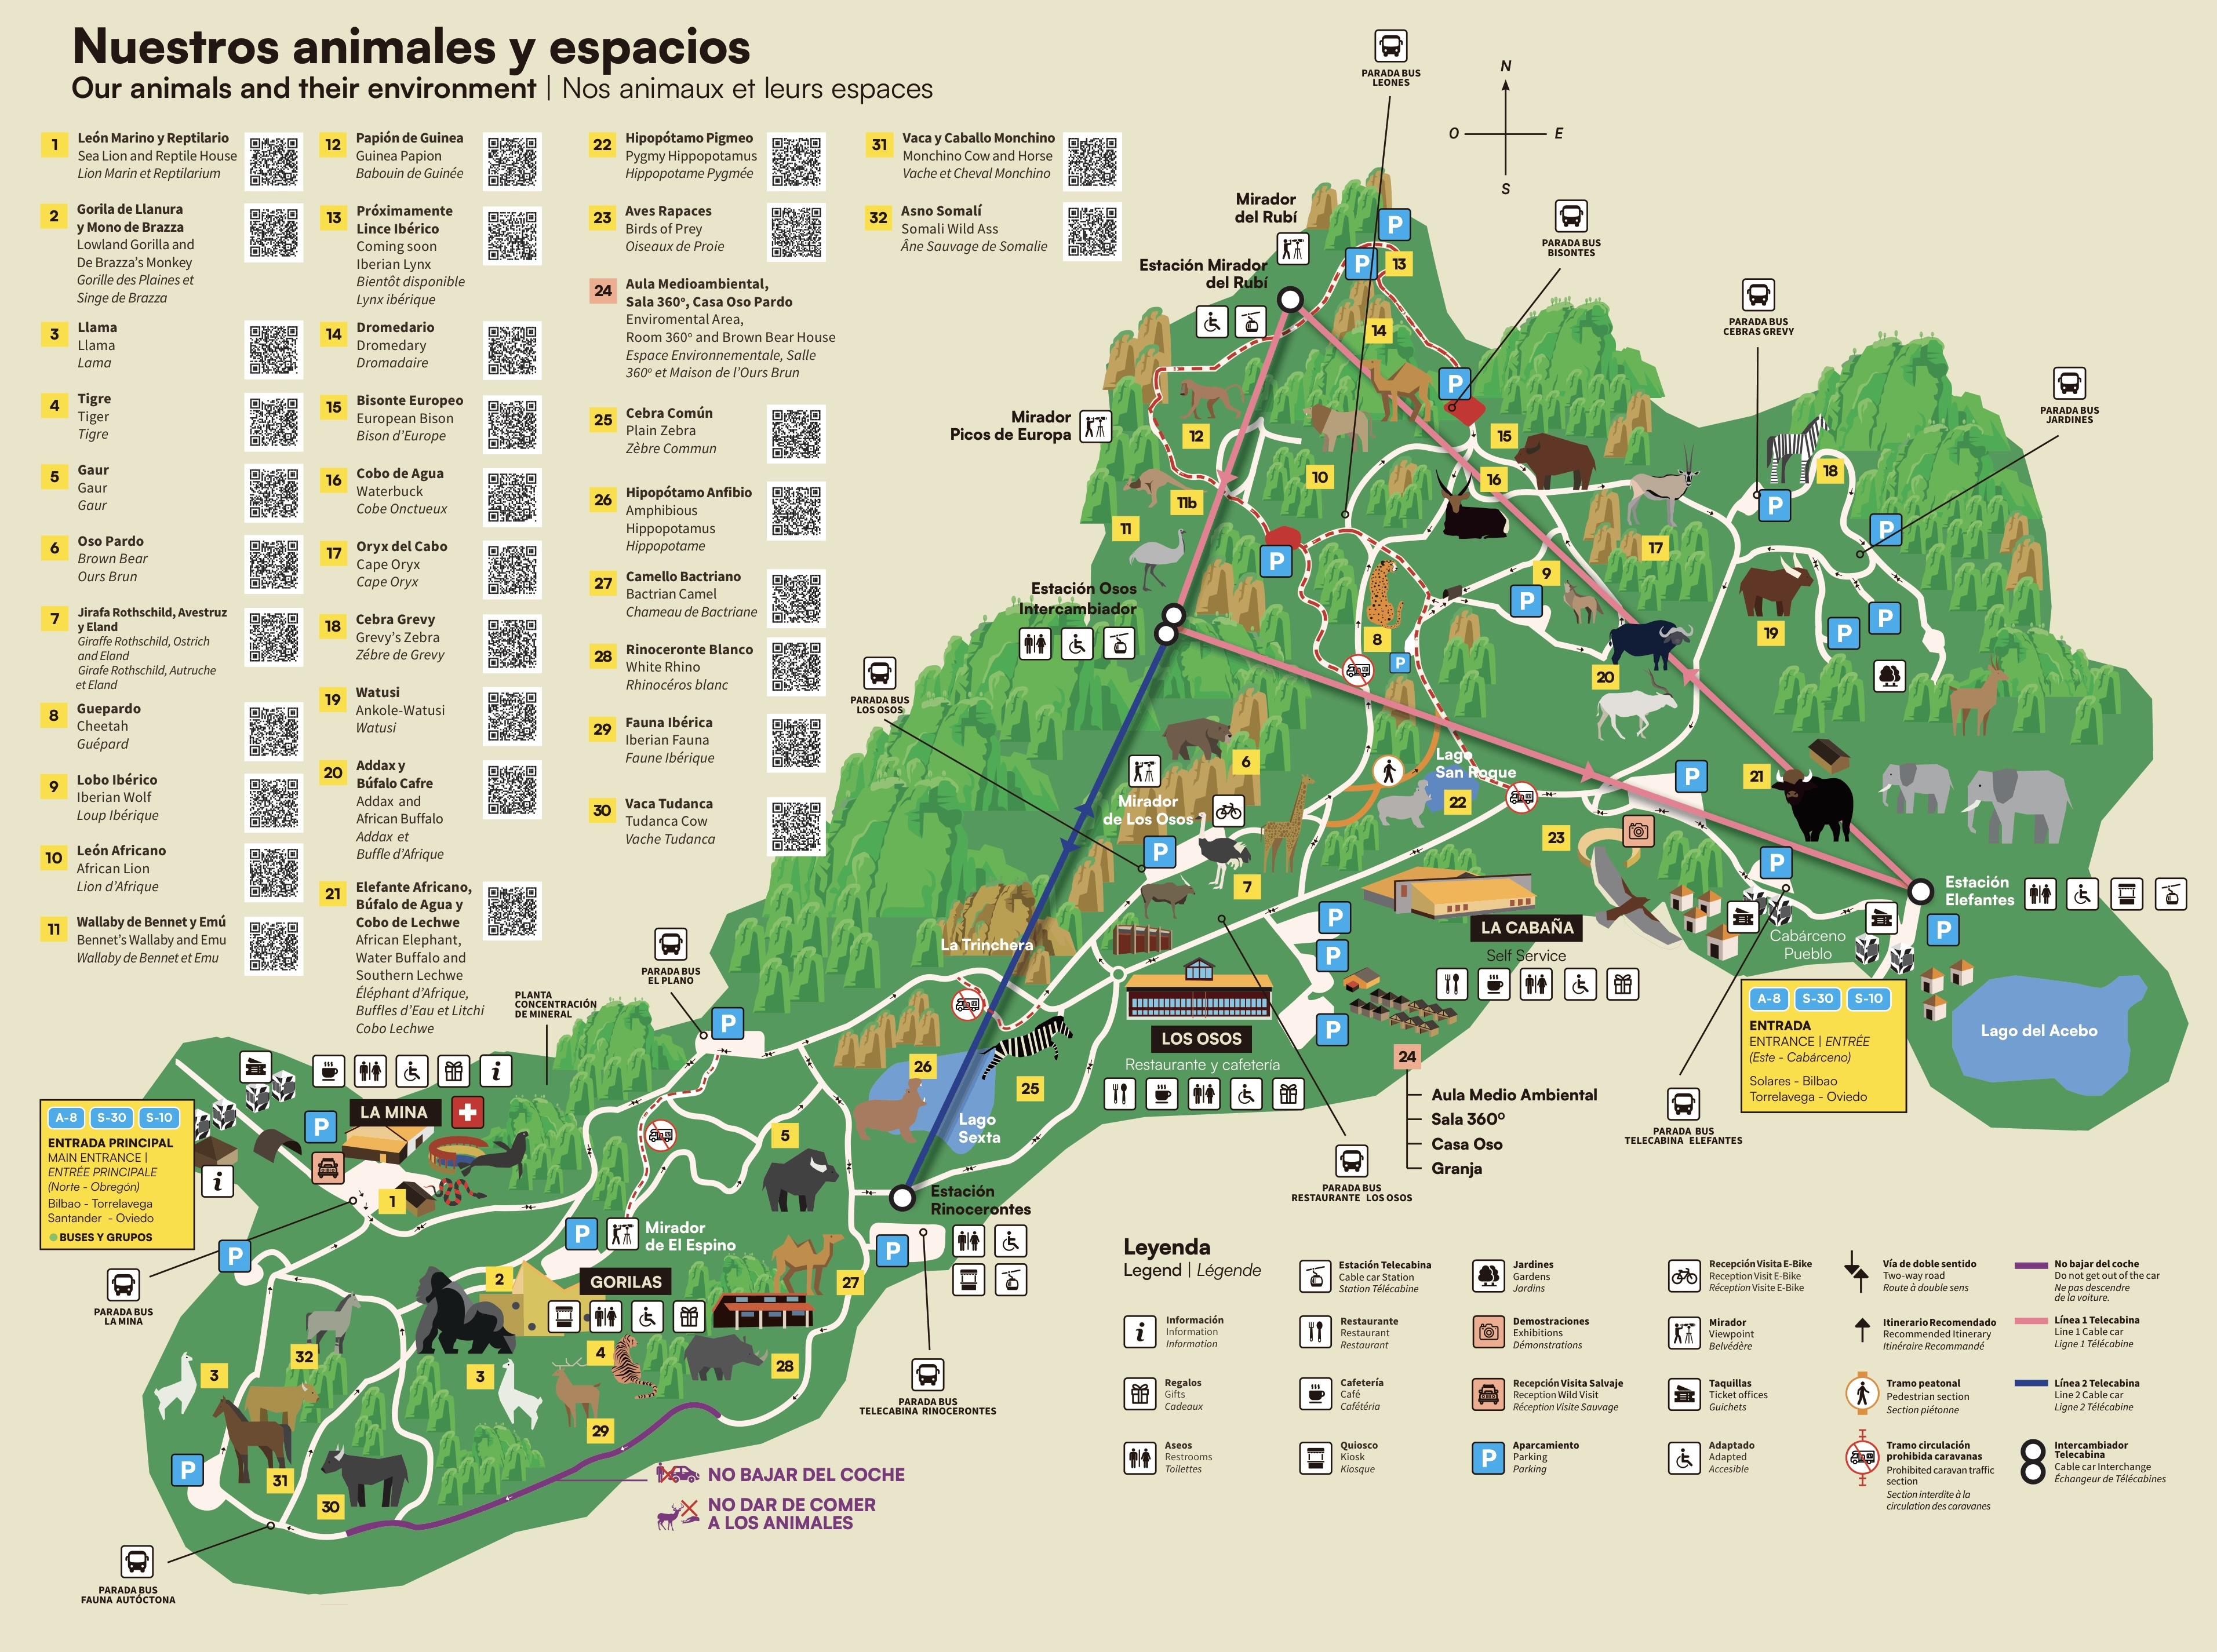

The question arises naturally: **Is the official recommended route the most optimal path in terms of distance?**

To solve the mismatch problem between enclosures (some OpenStreetMap names don't match 1:1, some split, and others are grouped together), we will establish a **heuristic mapping** from our filtered OSM list to the numbers on the official map. Once we have a "fixed sequential order", we will use **Dynamic Programming (Viterbi Algorithm)** to select the ideal parking lot for the recommended route and compare the final distances.

In [1]:
import pickle
import numpy as np
import pandas as pd
import folium
import math

In [2]:
# 1. Load TSP calculation data from disk
with open('../data/processed/optimization_results.pkl', 'rb') as f:
    data = pickle.load(f)

osm_names = data['names']
candidate_nodes = data['candidate_nodes']
node_distances = data['dist_between_nodes']
optimal_route_names = data['optimal_route_names']
optimal_distance = data['optimal_distance']

print(f"Nodes processed by OSM: {len(osm_names)}")
print(f"Optimal TSP Distance (Model 02): {optimal_distance / 1000:.2f} km")

Nodes processed by OSM: 31
Optimal TSP Distance (Model 02): 19.84 km


## 1. Heuristic Mapping (Official -> OSM)

We will align the route based on the photographic map. Since we have OSM enclosures that do not exist individually (like *Llama (1)* and *(2)*), or *Jaguar*, we will assign them logical decimal numbers to fit them into the correct path segment.

In [3]:
# Dictionary of positions from the official map [1 to 32]. 
# Missing ones are interpolated geographically close to their species (e.g. Llama (2) or Watusi (2)).
official_mapping = {
    'Main Entrance': 0,                      # Start
    'Reptilario/Leones Marinos': 1,          # 1
    'Gorila/Tigre': 2,                       # 2 and 4 on the official map
    'Llama': 3,                              # 3
    'Gaur': 5,                               # 5
    'Oso': 6,                                # 6
    'Jirafa, Avestruz y Eland': 7,           # 7
    'Guepardo': 8,                           # 8
    'Lobo': 9,                               # 9
    'León': 10,                              # 10
    'Wallaby de Bennet y Emú': 11,           # 11
    'Papion de Guinea': 12,                  # 12
    'Linces': 13,                            # 13
    'Dromedario': 14,                        # 14
    'Bisonte Europeo': 15,                   # 15
    'Cobos de agua': 16,                     # 16
    'Oryx del Cabo': 17,                     # 17
    'Cebras Grevy': 18,                      # 18
    'Watusi': 19,                            # 19
    'Addax y Búfalo Cafre': 20,              # 20
    'Elefante Africano, Búfalo de agua y Cobo de Lechwe': 21, # 21
    'Hipopótamos pigmeos': 22,               # 22
    'Aves rapaces/Granja': 23,               # 23 and 24
    'Cebra': 25,                             # 25
    'Hipopótamo': 26,                        # 26
    'Camello Bactriano': 27,                 # 27
    'Rinoceronte Blanco': 28,                # 28
    'Fauna Ibérica': 29,                     # 29
    'Vaca Tudanca': 30,                      # 30
    'Vaca y Caballo Monchino': 31,           # 31
    'Asno Somalí': 32                        # 32
}

# The recommended official route is the ascending order of this dictionary,
# having to return to the 'Main Entrance' at the end.
official_order_names = sorted(osm_names, key=lambda x: official_mapping.get(x, 99))
official_order_names.append('Main Entrance') # Return to the beginning

print("Enclosure sequence based on the Official map:")
print(" -> ".join(official_order_names))

Enclosure sequence based on the Official map:
Main Entrance -> Reptilario/Leones Marinos -> Gorila/Tigre -> Llama -> Gaur -> Oso -> Jirafa, Avestruz y Eland -> Guepardo -> Lobo -> León -> Wallaby de Bennet y Emú -> Papion de Guinea -> Linces -> Dromedario -> Bisonte Europeo -> Cobos de agua -> Oryx del Cabo -> Cebras Grevy -> Watusi -> Addax y Búfalo Cafre -> Elefante Africano, Búfalo de agua y Cobo de Lechwe -> Hipopótamos pigmeos -> Aves rapaces/Granja -> Cebra -> Hipopótamo -> Camello Bactriano -> Rinoceronte Blanco -> Fauna Ibérica -> Vaca Tudanca -> Vaca y Caballo Monchino -> Asno Somalí -> Main Entrance


## 2. Dynamic Programming (Viterbi)

Given a **strictly sequential order**, the only degree of freedom left is **which exact parking lot** to choose if an enclosure has multiple valid options. Solving this is the classic traveling salesperson problem with a fixed path but a graph of options, efficiently solvable using dynamic programming.

In [4]:
def resolve_fixed_sequence_distance(sequence_names, candidates_dict, distance_matrix):
    """
    Calculates the minimum distance by traversing the `sequence_names` sequence in order.
    """
    num_steps = len(sequence_names)
    
    # dp[step_id][node_id] = (accumulated_minimum_distance, previous_parent_node)
    dp = [{} for _ in range(num_steps)]
    
    # Initialize step 0 (Main Entrance)
    start_name = sequence_names[0]
    for start_node in candidates_dict[start_name]:
        dp[0][start_node] = (0, None)
        
    # Iterate sequence through each node
    for i in range(1, num_steps):
        prev_name = sequence_names[i-1]
        curr_name  = sequence_names[i]
        
        prev_nodes = candidates_dict[prev_name]
        curr_nodes  = candidates_dict[curr_name]
        
        for curr_node in curr_nodes:
            best_dist = math.inf
            best_parent = None
            
            for prev_node in prev_nodes:
                if prev_node in dp[i-1]:
                    transition_cost = distance_matrix.get((prev_node, curr_node), math.inf)
                    total_cost = dp[i-1][prev_node][0] + transition_cost
                    
                    if total_cost < best_dist:
                        best_dist = total_cost
                        best_parent = prev_node
            
            if best_dist < math.inf:
                dp[i][curr_node] = (best_dist, best_parent)
                
    # Search for the lowest cost in the last step (return home)
    best_final_cost = math.inf
    for final_node, (dist, parent) in dp[-1].items():
        if dist < best_final_cost:
            best_final_cost = dist
            
    return best_final_cost

In [5]:
# Evaluate the best choice of parking lots keeping the mandatory official route
recommended_distance = resolve_fixed_sequence_distance(official_order_names, candidate_nodes, node_distances)

print(f"Official Route (Recommended): {recommended_distance / 1000:.2f} km")
print(f"Optimal Route (Calculated):   {optimal_distance / 1000:.2f} km")

Official Route (Recommended): 30.27 km
Optimal Route (Calculated):   19.84 km


In [7]:
saved_km = (recommended_distance - optimal_distance) / 1000
improvement_pct = ((recommended_distance - optimal_distance) / recommended_distance) * 100
print(f"Using the optimal route would now save: {saved_km:.2f} km")
print(f"{improvement_pct:.1f}% less driving! More time to enjoy Cabárceno :)")

Using the optimal route would now save: 10.43 km
34.5% less driving! More time to enjoy Cabárceno :)
